<a href="https://colab.research.google.com/github/Elijah-Mumo/XAI_ELIAS_DS_R_Projects-crispy_waffle/blob/main/Loan_default.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Table of Contents
1. [Load and Inspect Training Data](#load-and-inspect-training-data)
2. [Preprocess Training Data](#preprocess-training-data)
   - [Feature Engineering (Dates)](#feature-engineering-dates)
   - [Drop 'referredby'](#drop-referredby)
   - [Drop 'customerid', 'loannumber'](#drop-customerid-loannumber)
   - [Analyze Time-Based Features](#analyze-time-based-features)
   - [Drop Time-Based Features](#drop-time-based-features)
   - [Analyze Loan Amount vs. Default](#analyze-loan-amount-vs-default)
3. [Load and Inspect Demographics Data](#load-and-inspect-demographics-data)
   - [Demographics Data Preprocessing](#demographics-data-preprocessing)
   - [Handle Missing Values](#handle-missing-values)
   - [One-Hot Encode Categorical Features](#one-hot-encode-categorical-features)
   - [Handle Missing Categorical Features](#handle-missing-categorical-features)
   - [Merge Demographics Data](#merge-demographics-data)
4. [Load and Inspect Previous Loans Data](#load-and-inspect-previous-loans-data)
   - [Previous Loans Data Preprocessing](#previous-loans-data-preprocessing)
   - [Feature Engineering (Previous Loans)](#feature-engineering-previous-loans)
   - [Aggregate Previous Loan Features](#aggregate-previous-loan-features)
   - [Merge Previous Loan Aggregates](#merge-previous-loan-aggregates)
   - [Handle Missing Aggregated Features](#handle-missing-aggregated-features)
5. [Prepare Test Data](#prepare-test-data)
   - [Merge Test Data](#merge-test-data)
   - [Fill Missing Test Data](#fill-missing-test-data)
6. [Prepare Features and Target for Modeling](#prepare-features-and-target-for-modeling)
7. [Model Training and Prediction (XGBoost)](#model-training-and-prediction-xgboost)
8. [Model Training and Prediction (K-Nearest Neighbors)](#model-training-and-prediction-k-nearest-neighbors)


## 1. Load and Inspect Training Data

In [251]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Load the dataset (reloading to ensure original date strings are present)
trn_df= pd.read_csv('trainperf.csv')
trn_df

,customerid,systemloanid,loannumber,approveddate,creationdate,loanamount,totaldue,termdays,referredby,good_bad_flag
0,8a2a81a74ce8c05d014cfb32a0da1049,301994762,12,2017-07-25 08:22:56.000000,2017-07-25 07:22:47.000000,30000.0,34500.0,30,NaN,Good
1,8a85886e54beabf90154c0a29ae757c0,301965204,2,2017-07-05 17:04:41.000000,2017-07-05 16:04:18.000000,15000.0,17250.0,30,NaN,Good
2,8a8588f35438fe12015444567666018e,301966580,7,2017-07-06 14:52:57.000000,2017-07-06 13:52:51.000000,20000.0,22250.0,15,NaN,Good
3,8a85890754145ace015429211b513e16,301999343,3,2017-07-27 19:00:41.000000,2017-07-27 18:00:35.000000,10000.0,11500.0,15,NaN,Good
4,8a858970548359cc0154883481981866,301962360,9,2017-07-03 23:42:45.000000,2017-07-03 22:42:39.000000,40000.0,44000.0,30,NaN,Good
...,...,...,...,...,...,...,...,...,...,...
4363,8a858e6d58b0cc520158beeb14b22a5a,302003163,2,2017-07-30 09:19:42.000000,2017-07-30 08:18:30.000000,10000.0,13000.0,30,NaN,Bad
4364,8a858ee85cf400f5015cf44ab1c42d5c,301998967,2,2017-07-27 15:35:47.000000,2017-07-27 14:35:40.000000,10000.0,13000.0,30,NaN,Bad
4365,8a858f365b2547f3015b284597147c94,301995576,3,2017-07-25 16:25:57.000000,2017-07-25 15:24:47.000000,10000.0,11500.0,15,NaN,Bad
4366,8a858f935ca09667015ca0ee3bc63f51,301977679,2,2017-07-14 13:50:27.000000,2017-07-14 12:50:21.000000,10000.0,13000.0,30,8a858eda5c8863ff015c9dead65807bb,Bad


### Initial Data Overview

We begin by loading the `trainperf.csv` dataset, which contains the core loan performance information. We'll then perform initial inspections using `df.info()`, `df.describe()`, and check for missing values and duplicates to understand the dataset's structure and quality.

In [252]:
print(trn_df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4368 entries, 0 to 4367
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   customerid     4368 non-null   object 
 1   systemloanid   4368 non-null   int64  
 2   loannumber     4368 non-null   int64  
 3   approveddate   4368 non-null   object 
 4   creationdate   4368 non-null   object 
 5   loanamount     4368 non-null   float64
 6   totaldue       4368 non-null   float64
 7   termdays       4368 non-null   int64  
 8   referredby     587 non-null    object 
 9   good_bad_flag  4368 non-null   object 
dtypes: float64(2), int64(3), object(5)
memory usage: 341.4+ KB
None


In [253]:
print(trn_df.describe())

print(trn_df.isnull().sum())

       systemloanid   loannumber    loanamount      totaldue     termdays
count  4.368000e+03  4368.000000   4368.000000   4368.000000  4368.000000
mean   3.019810e+08     5.172390  17809.065934  21257.377679    29.261676
std    1.343115e+04     3.653569  10749.694571  11943.510416    11.512519
min    3.019585e+08     2.000000  10000.000000  10000.000000    15.000000
25%    3.019691e+08     2.000000  10000.000000  13000.000000    30.000000
50%    3.019801e+08     4.000000  10000.000000  13000.000000    30.000000
75%    3.019935e+08     7.000000  20000.000000  24500.000000    30.000000
max    3.020040e+08    27.000000  60000.000000  68100.000000    90.000000
customerid          0
systemloanid        0
loannumber          0
approveddate        0
creationdate        0
loanamount          0
totaldue            0
termdays            0
referredby       3781
good_bad_flag       0
dtype: int64


In [254]:
trn_df.duplicated().sum()

np.int64(0)

In [255]:
print(trn_df.isnull().sum())

customerid          0
systemloanid        0
loannumber          0
approveddate        0
creationdate        0
loanamount          0
totaldue            0
termdays            0
referredby       3781
good_bad_flag       0
dtype: int64


In [256]:
trn_df['good_bad_flag'] = trn_df['good_bad_flag'].map({'Good': 1, 'Bad': 0})
print(trn_df['good_bad_flag'].value_counts())

good_bad_flag
1    3416
0     952
Name: count, dtype: int64


### Convert Target Variable

The `good_bad_flag` column, which indicates loan performance, is currently categorical ('Good', 'Bad'). We convert it to a numerical representation (1 for 'Good', 0 for 'Bad') for model training.

In [257]:
import numpy as np
import pandas as pd

for col in ['approveddate', 'creationdate']:
    # Convert to datetime objects, letting pandas infer the format
    # Use errors='coerce' to turn unparseable dates into NaT gracefully
    trn_df[col] = pd.to_datetime(trn_df[col], errors='coerce')

# Define an epoch for duration calculation (e.g., '1970-01-01')
epoch = pd.to_datetime('1970-01-01')

trn_df['approval_lag'] = (trn_df['approveddate'] - trn_df['creationdate']).dt.total_seconds() / 60
trn_df['approved_duration_minutes'] = (trn_df['approveddate'] - epoch).dt.total_seconds() / 60
trn_df['creation_duration_minutes'] = (trn_df['creationdate'] - epoch).dt.total_seconds() / 60

print(trn_df[['approveddate', 'creationdate', 'approval_lag']].head())

         approveddate        creationdate  approval_lag
0 2017-07-25 08:22:56 2017-07-25 07:22:47     60.150000
1 2017-07-05 17:04:41 2017-07-05 16:04:18     60.383333
2 2017-07-06 14:52:57 2017-07-06 13:52:51     60.100000
3 2017-07-27 19:00:41 2017-07-27 18:00:35     60.100000
4 2017-07-03 23:42:45 2017-07-03 22:42:39     60.100000


## 2. Preprocess Training Data

### Feature Engineering (Dates)

Date columns such as `approveddate` and `creationdate` often contain valuable temporal information. We convert these to datetime objects and extract features like `approval_lag` (time between creation and approval) and `approved_duration_minutes`/`creation_duration_minutes` (time since epoch). Errors during conversion are handled gracefully by coercing invalid dates to `NaT`.

In [258]:
trn_df = trn_df.drop('referredby', axis=1, errors='ignore')

### Drop 'referredby'

The `referredby` column has a high percentage of missing values and was deemed not useful for the model, so we remove it. The `errors='ignore'` argument prevents an error if the column has already been dropped.

In [259]:
trn_df.drop(columns=['customerid', 'loannumber'], inplace=True, errors='ignore')

### Drop 'customerid', 'loannumber'

We drop the `customerid` and `loannumber` columns as they are unique identifiers and not direct features for the model. `customerid` will be retained for merging with other datasets later.

In [260]:
trn_df.head()

,systemloanid,approveddate,creationdate,loanamount,totaldue,termdays,good_bad_flag,approval_lag,approved_duration_minutes,creation_duration_minutes
0,301994762,2017-07-25 08:22:56,2017-07-25 07:22:47,30000.0,34500.0,30,1,60.150000,2.501618e+07,2.501612e+07
1,301965204,2017-07-05 17:04:41,2017-07-05 16:04:18,15000.0,17250.0,30,1,60.383333,2.498790e+07,2.498784e+07
2,301966580,2017-07-06 14:52:57,2017-07-06 13:52:51,20000.0,22250.0,15,1,60.100000,2.498921e+07,2.498915e+07
3,301999343,2017-07-27 19:00:41,2017-07-27 18:00:35,10000.0,11500.0,15,1,60.100000,2.501970e+07,2.501964e+07
4,301962360,2017-07-03 23:42:45,2017-07-03 22:42:39,40000.0,44000.0,30,1,60.100000,2.498542e+07,2.498536e+07


Pearson correlation (with binary good_bad_flag):
approval_lag                -0.028459
approved_duration_minutes    0.008048
creation_duration_minutes    0.008143
Name: good_bad_flag, dtype: float64

Spearman and Point-biserial (value, p-value):
approval_lag: spearman=0.0105, p=0.4859; pointbiserial=-0.0285, p=0.06001
approved_duration_minutes: spearman=0.0061, p=0.6858; pointbiserial=0.0080, p=0.5949
creation_duration_minutes: spearman=0.0062, p=0.6822; pointbiserial=0.0081, p=0.5906

T-tests (Bad vs Good):
approval_lag: t=1.0519, p=0.2931
approved_duration_minutes: t=-0.5256, p=0.5993
creation_duration_minutes: t=-0.5318, p=0.5949


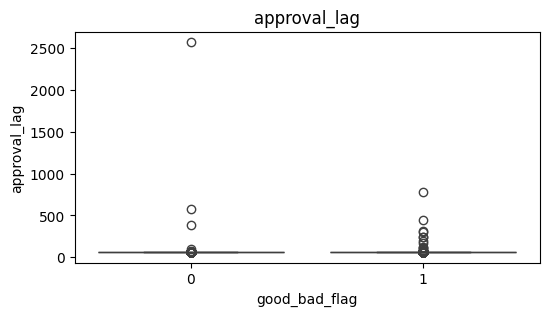

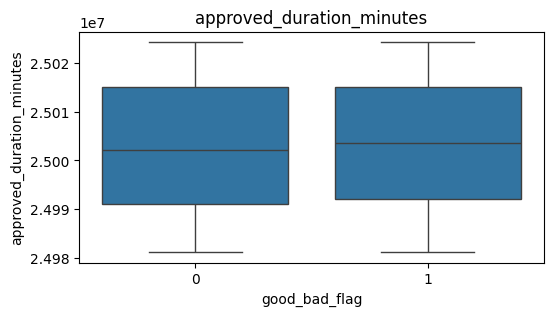

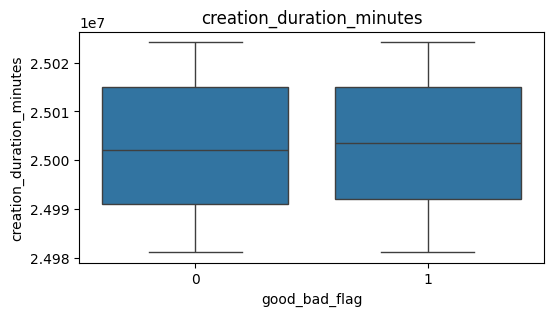


Logistic regression coefficients (standardized):
approval_lag: coef=-0.0607, odds_ratio=0.9411
approved_duration_minutes: coef=0.0102, odds_ratio=1.0102
creation_duration_minutes: coef=0.0104, odds_ratio=1.0104


In [261]:
# correlation coefficients
numeric = ['approval_lag', 'approved_duration_minutes', 'creation_duration_minutes']

# Ensure 'good_bad_flag' is numeric before correlation calculation
if trn_df['good_bad_flag'].dtype == 'object':
    trn_df['good_bad_flag'] = trn_df['good_bad_flag'].map({'Good': 1, 'Bad': 0})

print("Pearson correlation (with binary good_bad_flag):")
print(trn_df[numeric + ['good_bad_flag']].corr()['good_bad_flag'].loc[numeric])

from scipy.stats import spearmanr, pointbiserialr, ttest_ind
print("\nSpearman and Point-biserial (value, p-value):")
for col in numeric:
        sp = spearmanr(trn_df[col], trn_df['good_bad_flag'], nan_policy='omit')
        pb = pointbiserialr(trn_df['good_bad_flag'], trn_df[col])
        print(f"{col}: spearman={sp.correlation:.4f}, p={sp.pvalue:.4g}; pointbiserial={pb.correlation:.4f}, p={pb.pvalue:.4g}")

# two-sample t-test
print("\nT-tests (Bad vs Good):")
for col in numeric:
        g0 = trn_df.loc[trn_df['good_bad_flag']==0, col].dropna()
        g1 = trn_df.loc[trn_df['good_bad_flag']==1, col].dropna()
        t, p = ttest_ind(g0, g1, nan_policy='omit', equal_var=False)
        print(f"{col}: t={t:.4f}, p={p:.4g}")

# visual checks
import matplotlib.pyplot as plt
import seaborn as sns
for col in numeric:
        plt.figure(figsize=(6,3))
        sns.boxplot(x='good_bad_flag', y=col, data=trn_df)
        plt.title(col)
        plt.show()

# logistic regression for feature importance (standardized)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

X = trn_df[numeric].fillna(0)
y = trn_df['good_bad_flag']
sc = StandardScaler()
Xs = sc.fit_transform(X)
clf = LogisticRegression(max_iter=1000).fit(Xs, y)
coef = clf.coef_[0]
odds_ratios = np.exp(coef)
print("\nLogistic regression coefficients (standardized):")
for name, c, o in zip(numeric, coef, odds_ratios):
        print(f"{name}: coef={c:.4f}, odds_ratio={o:.4f}")

### Analyze Time-Based Features

We perform various statistical analyses (Pearson correlation, Spearman, Point-biserial, T-tests, logistic regression) and visual checks (boxplots) to determine the predictive power of the engineered time-based features (`approval_lag`, `approved_duration_minutes`, `creation_duration_minutes`) with respect to the `good_bad_flag`.

In [262]:
trn_df = trn_df.drop(columns=['approval_lag', 'approved_duration_minutes', 'creation_duration_minutes'])
trn_df.head()

,systemloanid,approveddate,creationdate,loanamount,totaldue,termdays,good_bad_flag
0,301994762,2017-07-25 08:22:56,2017-07-25 07:22:47,30000.0,34500.0,30,1
1,301965204,2017-07-05 17:04:41,2017-07-05 16:04:18,15000.0,17250.0,30,1
2,301966580,2017-07-06 14:52:57,2017-07-06 13:52:51,20000.0,22250.0,15,1
3,301999343,2017-07-27 19:00:41,2017-07-27 18:00:35,10000.0,11500.0,15,1
4,301962360,2017-07-03 23:42:45,2017-07-03 22:42:39,40000.0,44000.0,30,1


### Drop Time-Based Features

Based on the previous analysis, the engineered time-based features show weak correlations and non-significant differences with the target variable. Therefore, they are dropped from the training data.

<Axes: xlabel='good_bad_flag', ylabel='loanamount'>

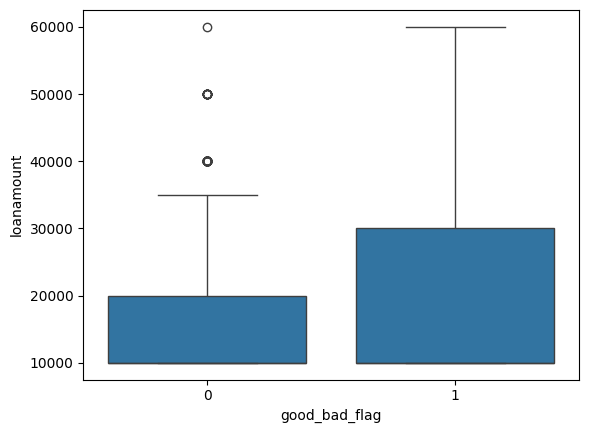

In [263]:
sns.boxplot(x=trn_df['good_bad_flag'], y=trn_df['loanamount'])

### Analyze Loan Amount vs. Default

Visualize the relationship between `loanamount` and `good_bad_flag` using a boxplot to understand if loan amount is a significant predictor of default.

In [264]:
trn_df.shape

(4368, 7)

In [265]:
# Load the dataset
test_df= pd.read_csv('testperf.csv')
test_df

,customerid,systemloanid,loannumber,approveddate,creationdate,loanamount,totaldue,termdays,referredby
0,8a858899538ddb8e015390510b321f08,301998974,4,40:48.0,39:35.0,10000,12250.0,30,NaN
1,8a858959537a097401537a4e316e25f7,301963615,10,43:40.0,42:34.0,40000,44000.0,30,NaN
2,8a8589c253ace09b0153af6ba58f1f31,301982236,6,15:11.0,15:04.0,20000,24500.0,30,NaN
3,8a858e095aae82b7015aae86ca1e030b,301971730,8,00:54.0,00:49.0,30000,34500.0,30,NaN
4,8a858e225a28c713015a30db5c48383d,301959177,4,04:33.0,04:27.0,20000,24500.0,30,NaN
...,...,...,...,...,...,...,...,...,...
1445,8a858fb45bb59c21015bb88a191f58f2,301991141,3,47:02.0,46:53.0,10000,11500.0,15,NaN
1446,8a858fcb5b00cc54015b0253ced26a5f,301963018,3,00:45.0,04:05.0,10000,13000.0,30,NaN
1447,8a858fde56eb02280156f59b976d46c0,301994653,9,09:40.0,09:33.0,40000,48000.0,60,NaN
1448,8a858e10570f2d65015717fcfec44996,301961483,14,47:54.0,46:49.0,60000,68100.0,90,NaN


## 3. Load and Inspect Demographics Data

We load the `traindemographics.csv` dataset, which contains demographic information about the customers. We perform an initial inspection of its shape, data types, and missing values.

In [266]:
Dtrn_df= pd.read_csv('traindemographics.csv')
Dtrn_df.head()

,customerid,birthdate,bank_account_type,longitude_gps,latitude_gps,bank_name_clients,bank_branch_clients,employment_status_clients,level_of_education_clients
0,8a858e135cb22031015cbafc76964ebd,1973-10-10 00:00:00.000000,Savings,3.319219,6.528604,GT Bank,NaN,NaN,NaN
1,8a858e275c7ea5ec015c82482d7c3996,1986-01-21 00:00:00.000000,Savings,3.325598,7.119403,Sterling Bank,NaN,Permanent,NaN
2,8a858e5b5bd99460015bdc95cd485634,1987-04-01 00:00:00.000000,Savings,5.746100,5.563174,Fidelity Bank,NaN,NaN,NaN
3,8a858efd5ca70688015cabd1f1e94b55,1991-07-19 00:00:00.000000,Savings,3.362850,6.642485,GT Bank,NaN,Permanent,NaN
4,8a858e785acd3412015acd48f4920d04,1982-11-22 00:00:00.000000,Savings,8.455332,11.971410,GT Bank,NaN,Permanent,NaN


In [267]:
print("Original Dtrn_df shape:", Dtrn_df.shape)
print(Dtrn_df.dtypes)
print("Missing fraction per column:")
print(Dtrn_df.isnull().mean().sort_values(ascending=False).head(20))

Original Dtrn_df shape: (4346, 9)
customerid                     object
birthdate                      object
bank_account_type              object
longitude_gps                 float64
latitude_gps                  float64
bank_name_clients              object
bank_branch_clients            object
employment_status_clients      object
level_of_education_clients     object
dtype: object
Missing fraction per column:
bank_branch_clients           0.988265
level_of_education_clients    0.864933
employment_status_clients     0.149103
customerid                    0.000000
birthdate                     0.000000
latitude_gps                  0.000000
longitude_gps                 0.000000
bank_account_type             0.000000
bank_name_clients             0.000000
dtype: float64


In [268]:
Dtrn_df = Dtrn_df.drop(
    columns=['loannumber', 'referredby', 'applicationid'],
    errors='ignore'
)

### Demographics Data Preprocessing

We drop irrelevant identifier columns like `loannumber`, `referredby`, and `applicationid` from the demographics data. `customerid` is kept for merging.

In [269]:
import numpy as np

cols = ['bank_branch_clients', 'employment_status_clients', 'level_of_education_clients']

for col in cols:
    Dtrn_df[col] = (
        Dtrn_df[col]
        .replace(['nan', 'None', '', 'NULL'], np.nan)
    )

### Clean Categorical String Representations

Standardize missing value representations (e.g., 'nan', 'None', empty strings) in selected categorical columns by replacing them with `np.nan` for consistent handling.

In [270]:
Dtrn_df[['bank_branch_clients', 'employment_status_clients', 'level_of_education_clients']].isnull().sum()

,0
bank_branch_clients,4295
employment_status_clients,648
level_of_education_clients,3759


In [271]:
Dtrn_df['employment_status_clients'] = (
    Dtrn_df['employment_status_clients']
    .fillna('unknown')
)

Dtrn_df = pd.get_dummies(
    Dtrn_df,
    columns=['employment_status_clients'],
    drop_first=False
)

### One-Hot Encode Categorical Features

Categorical features, such as `employment_status_clients` and `level_of_education_clients`, are converted into numerical representations using one-hot encoding. For `employment_status_clients`, missing values are imputed as 'unknown' before encoding. For `level_of_education_clients`, `drop_first=True` is used to avoid multicollinearity.

In [272]:
Dtrn_df = pd.get_dummies(
    Dtrn_df,
    columns=['level_of_education_clients'],
    drop_first=True
)

In [273]:
Dtrn_df = Dtrn_df.drop(columns=['bank_branch_clients'], errors='ignore')

### Drop 'bank_branch_clients'

The `bank_branch_clients` column is dropped due to a very high number of missing values and limited utility.

In [274]:
Dtrn_df

,customerid,birthdate,bank_account_type,longitude_gps,latitude_gps,bank_name_clients,employment_status_clients_Contract,employment_status_clients_Permanent,employment_status_clients_Retired,employment_status_clients_Self-Employed,employment_status_clients_Student,employment_status_clients_Unemployed,employment_status_clients_unknown,level_of_education_clients_Post-Graduate,level_of_education_clients_Primary,level_of_education_clients_Secondary
0,8a858e135cb22031015cbafc76964ebd,1973-10-10 00:00:00.000000,Savings,3.319219,6.528604,GT Bank,False,False,False,False,False,False,True,False,False,False
1,8a858e275c7ea5ec015c82482d7c3996,1986-01-21 00:00:00.000000,Savings,3.325598,7.119403,Sterling Bank,False,True,False,False,False,False,False,False,False,False
2,8a858e5b5bd99460015bdc95cd485634,1987-04-01 00:00:00.000000,Savings,5.746100,5.563174,Fidelity Bank,False,False,False,False,False,False,True,False,False,False
3,8a858efd5ca70688015cabd1f1e94b55,1991-07-19 00:00:00.000000,Savings,3.362850,6.642485,GT Bank,False,True,False,False,False,False,False,False,False,False
4,8a858e785acd3412015acd48f4920d04,1982-11-22 00:00:00.000000,Savings,8.455332,11.971410,GT Bank,False,True,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4341,8a858f155554552501555588ca2b3b40,1985-12-13 00:00:00.000000,Other,3.236753,7.030168,Stanbic IBTC,False,True,False,False,False,False,False,False,False,False
4342,8a858fc65cf978f4015cf97cee3a02ce,1982-07-01 00:00:00.000000,Savings,7.013750,4.875662,GT Bank,False,False,False,False,False,False,True,False,False,False
4343,8a858f4f5b66de3a015b66fc83c61902,1989-09-26 00:00:00.000000,Savings,6.295530,7.092508,GT Bank,False,True,False,False,False,False,False,False,False,False
4344,8aaae7a74400b28201441c8b62514150,1985-09-06 00:00:00.000000,Savings,3.354206,6.539070,GT Bank,False,True,False,False,False,False,False,False,True,False


In [275]:
for col in Dtrn_df.select_dtypes(include='object').columns:
    Dtrn_df[col] = (
        Dtrn_df[col]
        .astype(str)
        .str.strip()
        .replace({'nan': np.nan, 'None': np.nan, '': np.nan})
    )

### Standardize Object Columns and Convert Types

Iterate through object columns to clean string data (strip whitespace, replace common 'nan'/'None' strings), and then attempt to convert them to numeric, datetime, or binary types if applicable. Missing value indicator columns are created for any column with missing values.

In [276]:
for col in Dtrn_df.select_dtypes(include='object').columns:
    sample = Dtrn_df[col].dropna().astype(str)
    if not sample.empty and sample.str.match(r'^-?\d+(\.\d+)?$').all():
        Dtrn_df[col] = pd.to_numeric(Dtrn_df[col], errors='coerce')

In [277]:
for col in Dtrn_df.select_dtypes(include='object').columns:
    sample = Dtrn_df[col].dropna().astype(str)
    if not sample.empty and sample.str.match(r'^\d{4}-\d{2}-\d{2}').any():
        Dtrn_df[col] = pd.to_datetime(Dtrn_df[col], errors='coerce')

In [278]:
binary_map = {
    'Yes': 1, 'No': 0, 'Y': 1, 'N': 0,
    'Male': 1, 'Female': 0, 'M': 1, 'F': 0,
    'yes': 1, 'no': 0, 'male': 1, 'female': 0
}
for col in Dtrn_df.select_dtypes(include='object').columns:
    uniques = Dtrn_df[col].dropna().unique()
    if len(uniques) <= 2:
        mapped = Dtrn_df[col].map(binary_map)
        if mapped.notna().sum() == Dtrn_df[col].notna().sum():
            Dtrn_df[col] = mapped.astype('float')

In [279]:
for col in Dtrn_df.columns:
    if Dtrn_df[col].isnull().any():
        Dtrn_df[f'{col}_missing'] = Dtrn_df[col].isnull().astype(int)

In [280]:
if 'age' in Dtrn_df.columns:
    Dtrn_df['age_group'] = pd.cut(
        Dtrn_df['age'],
        bins=[0, 25, 35, 50, 65, 120],
        labels=['<25', '25-35', '35-50', '50-65', '65+']
    )

if {'monthlyincome', 'loanamount'}.issubset(Dtrn_df.columns):
    Dtrn_df['income_to_loan'] = Dtrn_df['monthlyincome'] / Dtrn_df['loanamount']

if {'monthlyincome', 'termdays'}.issubset(Dtrn_df.columns):
    Dtrn_df['income_per_term_day'] = Dtrn_df['monthlyincome'] / Dtrn_df['termdays']

### Create Age and Income-Related Features

If available, create `age_group` from `age` and ratios like `income_to_loan` and `income_per_term_day` to capture financial leverage and affordability.

In [281]:
for col in Dtrn_df.select_dtypes(include=['int64', 'float64']).columns:
    Dtrn_df[col] = Dtrn_df[col].fillna(Dtrn_df[col].median())

for col in Dtrn_df.select_dtypes(include=['object', 'category']).columns:
    if Dtrn_df[col].isnull().any():
        mode = Dtrn_df[col].mode(dropna=True)
        fill_value = mode.iloc[0] if not mode.empty else 'missing'
        Dtrn_df[col] = Dtrn_df[col].fillna(fill_value)


### Impute Missing Values

Missing numerical values in `Dtrn_df` are imputed using the median of their respective columns. For categorical/object columns, missing values are filled with the mode.

In [282]:
for col in Dtrn_df.select_dtypes(include='object').columns:
    if Dtrn_df[col].nunique() < 30:
        Dtrn_df[col] = Dtrn_df[col].astype('category')

In [283]:
Dtrn_df.head()

,customerid,birthdate,bank_account_type,longitude_gps,latitude_gps,bank_name_clients,employment_status_clients_Contract,employment_status_clients_Permanent,employment_status_clients_Retired,employment_status_clients_Self-Employed,employment_status_clients_Student,employment_status_clients_Unemployed,employment_status_clients_unknown,level_of_education_clients_Post-Graduate,level_of_education_clients_Primary,level_of_education_clients_Secondary
0,8a858e135cb22031015cbafc76964ebd,1973-10-10,Savings,3.319219,6.528604,GT Bank,False,False,False,False,False,False,True,False,False,False
1,8a858e275c7ea5ec015c82482d7c3996,1986-01-21,Savings,3.325598,7.119403,Sterling Bank,False,True,False,False,False,False,False,False,False,False
2,8a858e5b5bd99460015bdc95cd485634,1987-04-01,Savings,5.746100,5.563174,Fidelity Bank,False,False,False,False,False,False,True,False,False,False
3,8a858efd5ca70688015cabd1f1e94b55,1991-07-19,Savings,3.362850,6.642485,GT Bank,False,True,False,False,False,False,False,False,False,False
4,8a858e785acd3412015acd48f4920d04,1982-11-22,Savings,8.455332,11.971410,GT Bank,False,True,False,False,False,False,False,False,False,False


In [284]:
# 1. Check duplicates
print("Full duplicates:", Dtrn_df.duplicated().sum())
print("Customer duplicates:", Dtrn_df['customerid'].duplicated().sum())

# 2. Remove exact duplicates
Dtrn_df = Dtrn_df.drop_duplicates()

# 3. Handle customer duplicates carefully (keep latest if time exists)
if 'creationdate' in Dtrn_df.columns:
    Dtrn_df = Dtrn_df.sort_values('creationdate').drop_duplicates('customerid', keep='last')

Full duplicates: 12
Customer duplicates: 12


### Handle Duplicates

Check for and remove duplicate rows based on all columns and specifically based on `customerid`. If a `creationdate` is available, the latest entry for a duplicate `customerid` is kept.

In [285]:
print("Missing values:", Dtrn_df.isnull().sum().sum())
print("Duplicate rows:", Dtrn_df.duplicated().sum())

# ensure uniqueness before merge
Dtrn_df = Dtrn_df.drop_duplicates(subset=['customerid'])

if 'customerid' in trn_df.columns:
    # Identify columns in Dtrn_df (excluding 'customerid') that might cause conflicts
    demog_cols = [col for col in Dtrn_df.columns if col != 'customerid']
    # Form the names of columns that would cause conflict if suffixed with '_main'
    conflicting_cols = [f'{col}_main' for col in demog_cols if f'{col}_main' in trn_df.columns]

    # Drop these conflicting columns from trn_df if they exist
    if conflicting_cols:
        trn_df = trn_df.drop(columns=conflicting_cols, errors='ignore')
        print(f"Dropped conflicting columns from trn_df: {conflicting_cols}")

    # Now perform the merge with explicit and distinct suffixes
    trn_df = trn_df.merge(
        Dtrn_df,
        on='customerid',
        how='left',
        validate='m:1',   # many trn rows to one customer row
        suffixes=('_main', '_demog') # Use distinct suffixes to prevent collision
    )

else:
    perf_id_map = pd.read_csv(
        r'trainperf.csv',
        usecols=['systemloanid', 'customerid']
    )

    trn_df = trn_df.merge(perf_id_map, on='systemloanid', how='left')

    # Identify columns in Dtrn_df (excluding 'customerid') that might cause conflicts
    demog_cols = [col for col in Dtrn_df.columns if col != 'customerid']
    conflicting_cols = [f'{col}_main' for col in demog_cols if f'{col}_main' in trn_df.columns]

    if conflicting_cols:
        trn_df = trn_df.drop(columns=conflicting_cols, errors='ignore')
        print(f"Dropped conflicting columns from trn_df: {conflicting_cols}")

    # Apply the same suffix strategy if this block is executed
    trn_df = trn_df.merge(Dtrn_df, on='customerid', how='left', validate='m:1', suffixes=('_main', '_demog'))

print("Final shape:", trn_df.shape)
print("Missing customerid:", trn_df['customerid'].isnull().sum())

Missing values: 0
Duplicate rows: 0
Final shape: (4368, 23)
Missing customerid: 0


### Merge Demographics Data

Merge the processed demographics data (`Dtrn_df`) into the main training DataFrame (`trn_df`) using `customerid`. Conflict resolution is implemented by explicitly dropping any columns from `trn_df` that would clash with `Dtrn_df` columns before the merge, and distinct suffixes are used for overlapping column names.

In [286]:
trn_df.head()

,systemloanid,approveddate,creationdate,loanamount,totaldue,termdays,good_bad_flag,customerid,birthdate,bank_account_type,...,employment_status_clients_Contract,employment_status_clients_Permanent,employment_status_clients_Retired,employment_status_clients_Self-Employed,employment_status_clients_Student,employment_status_clients_Unemployed,employment_status_clients_unknown,level_of_education_clients_Post-Graduate,level_of_education_clients_Primary,level_of_education_clients_Secondary
0,301994762,2017-07-25 08:22:56,2017-07-25 07:22:47,30000.0,34500.0,30,1,8a2a81a74ce8c05d014cfb32a0da1049,1972-01-15,Other,...,False,True,False,False,False,False,False,True,False,False
1,301965204,2017-07-05 17:04:41,2017-07-05 16:04:18,15000.0,17250.0,30,1,8a85886e54beabf90154c0a29ae757c0,1985-08-23,Savings,...,False,True,False,False,False,False,False,False,False,False
2,301966580,2017-07-06 14:52:57,2017-07-06 13:52:51,20000.0,22250.0,15,1,8a8588f35438fe12015444567666018e,1984-09-18,Other,...,False,True,False,False,False,False,False,False,False,False
3,301999343,2017-07-27 19:00:41,2017-07-27 18:00:35,10000.0,11500.0,15,1,8a85890754145ace015429211b513e16,1977-10-10,Savings,...,False,True,False,False,False,False,False,False,False,False
4,301962360,2017-07-03 23:42:45,2017-07-03 22:42:39,40000.0,44000.0,30,1,8a858970548359cc0154883481981866,1986-09-07,Other,...,False,True,False,False,False,False,False,False,True,False


In [287]:
Prvl_df= pd.read_csv('trainprevloans.csv')
Prvl_df.head()

,customerid,systemloanid,loannumber,approveddate,creationdate,loanamount,totaldue,termdays,closeddate,referredby,firstduedate,firstrepaiddate
0,8a2a81a74ce8c05d014cfb32a0da1049,301682320,2,2016-08-15 18:22:40.000000,2016-08-15 17:22:32.000000,10000.0,13000.0,30,2016-09-01 16:06:48.000000,NaN,2016-09-14 00:00:00.000000,2016-09-01 15:51:43.000000
1,8a2a81a74ce8c05d014cfb32a0da1049,301883808,9,2017-04-28 18:39:07.000000,2017-04-28 17:38:53.000000,10000.0,13000.0,30,2017-05-28 14:44:49.000000,NaN,2017-05-30 00:00:00.000000,2017-05-26 00:00:00.000000
2,8a2a81a74ce8c05d014cfb32a0da1049,301831714,8,2017-03-05 10:56:25.000000,2017-03-05 09:56:19.000000,20000.0,23800.0,30,2017-04-26 22:18:56.000000,NaN,2017-04-04 00:00:00.000000,2017-04-26 22:03:47.000000
3,8a8588f35438fe12015444567666018e,301861541,5,2017-04-09 18:25:55.000000,2017-04-09 17:25:42.000000,10000.0,11500.0,15,2017-04-24 01:35:52.000000,NaN,2017-04-24 00:00:00.000000,2017-04-24 00:48:43.000000
4,8a85890754145ace015429211b513e16,301941754,2,2017-06-17 09:29:57.000000,2017-06-17 08:29:50.000000,10000.0,11500.0,15,2017-07-14 21:18:43.000000,NaN,2017-07-03 00:00:00.000000,2017-07-14 21:08:35.000000


## 4. Load and Inspect Previous Loans Data

We load the `trainprevloans.csv` dataset, which contains information about customers' previous loan history. We inspect its descriptive statistics and missing values.

In [288]:
print(Prvl_df.describe())

print(Prvl_df.isnull().sum())

       systemloanid    loannumber    loanamount      totaldue      termdays
count  1.818300e+04  18183.000000  18183.000000  18183.000000  18183.000000
mean   3.018395e+08      4.189353  16501.237420  19573.202931     26.692790
std    9.367767e+04      3.249490   9320.547516  10454.245277     10.946556
min    3.016001e+08      1.000000   3000.000000   3450.000000     15.000000
25%    3.017766e+08      2.000000  10000.000000  11500.000000     15.000000
50%    3.018550e+08      3.000000  10000.000000  13000.000000     30.000000
75%    3.019197e+08      6.000000  20000.000000  24500.000000     30.000000
max    3.020003e+08     26.000000  60000.000000  68100.000000     90.000000
customerid             0
systemloanid           0
loannumber             0
approveddate           0
creationdate           0
loanamount             0
totaldue               0
termdays               0
closeddate             0
referredby         17157
firstduedate           0
firstrepaiddate        0
dtype: int64


In [289]:
Prvl_df = Prvl_df.drop(columns=['referredby'])

### Previous Loans Data Preprocessing

We drop the `referredby` column from `Prvl_df` due to a high number of missing values.

In [290]:
for col in ['approveddate','creationdate','closeddate','firstduedate','firstrepaiddate']:
    Prvl_df[col] = pd.to_datetime(Prvl_df[col])

### Convert Date Columns to Datetime

Convert all date-related columns in `Prvl_df` to datetime objects for proper temporal calculations.

In [291]:
Prvl_df['approval_delay'] = (
    pd.to_datetime(Prvl_df['approveddate']) -
    pd.to_datetime(Prvl_df['creationdate'])
).dt.days
Prvl_df['approval_delay'] = (
    (Prvl_df['approveddate'] - Prvl_df['creationdate'])
    .dt.total_seconds() / 3600
)

### Feature Engineering (Previous Loans)

Derive new features from `Prvl_df` such as `approval_delay` (time between loan creation and approval), `repayment_delay` (time between actual and scheduled repayment), `interest`, and `interest_rate`.

In [292]:
Prvl_df['repayment_delay'] = (
    pd.to_datetime(Prvl_df['firstrepaiddate']) -
    pd.to_datetime(Prvl_df['firstduedate'])
).dt.days

In [293]:
Prvl_df['interest'] = Prvl_df['totaldue'] - Prvl_df['loanamount']
Prvl_df['interest_rate'] = Prvl_df['interest'] / Prvl_df['loanamount']

In [294]:
Prvl_df.head()

,customerid,systemloanid,loannumber,approveddate,creationdate,loanamount,totaldue,termdays,closeddate,firstduedate,firstrepaiddate,approval_delay,repayment_delay,interest,interest_rate
0,8a2a81a74ce8c05d014cfb32a0da1049,301682320,2,2016-08-15 18:22:40,2016-08-15 17:22:32,10000.0,13000.0,30,2016-09-01 16:06:48,2016-09-14,2016-09-01 15:51:43,1.002222,-13,3000.0,0.30
1,8a2a81a74ce8c05d014cfb32a0da1049,301883808,9,2017-04-28 18:39:07,2017-04-28 17:38:53,10000.0,13000.0,30,2017-05-28 14:44:49,2017-05-30,2017-05-26 00:00:00,1.003889,-4,3000.0,0.30
2,8a2a81a74ce8c05d014cfb32a0da1049,301831714,8,2017-03-05 10:56:25,2017-03-05 09:56:19,20000.0,23800.0,30,2017-04-26 22:18:56,2017-04-04,2017-04-26 22:03:47,1.001667,22,3800.0,0.19
3,8a8588f35438fe12015444567666018e,301861541,5,2017-04-09 18:25:55,2017-04-09 17:25:42,10000.0,11500.0,15,2017-04-24 01:35:52,2017-04-24,2017-04-24 00:48:43,1.003611,0,1500.0,0.15
4,8a85890754145ace015429211b513e16,301941754,2,2017-06-17 09:29:57,2017-06-17 08:29:50,10000.0,11500.0,15,2017-07-14 21:18:43,2017-07-03,2017-07-14 21:08:35,1.001944,11,1500.0,0.15


In [295]:
Prvl_df = Prvl_df.drop(
    columns=[
        'systemloanid',
        'referredby',
        'approveddate',
        'creationdate',
        'closeddate',
        'firstduedate',
        'firstrepaiddate'
    ],
    errors='ignore'
)

print("Remaining columns:", Prvl_df.columns.tolist())

Remaining columns: ['customerid', 'loannumber', 'loanamount', 'totaldue', 'termdays', 'approval_delay', 'repayment_delay', 'interest', 'interest_rate']


### Drop Redundant Columns

Remove original date columns and `systemloanid` from `Prvl_df` after feature engineering, as their derived counterparts are now available.

In [296]:
Prvl_df['repayment_delay'] = Prvl_df['repayment_delay'].clip(lower=-30, upper=90)

### Clip Repayment Delay

To handle outliers or extreme values, `repayment_delay` is clipped to a range of -30 to 90 days.

In [297]:
Prvl_df['late_repayment_flag'] = (Prvl_df['repayment_delay'] > 0).astype(int)

### Create Late Repayment Flag

Create a binary flag `late_repayment_flag` indicating whether a previous loan was repaid late (repayment delay > 0).

In [298]:
Prvl_df.describe()

,loannumber,loanamount,totaldue,termdays,approval_delay,repayment_delay,interest,interest_rate,late_repayment_flag
count,18183.000000,18183.000000,18183.000000,18183.000000,18183.000000,18183.000000,18183.000000,18183.000000,18183.000000
mean,4.189353,16501.237420,19573.202931,26.692790,1.068450,-2.528241,3071.965512,0.203706,0.173844
std,3.249490,9320.547516,10454.245277,10.946556,1.047247,8.920539,1493.967266,0.074354,0.378985
min,1.000000,3000.000000,3450.000000,15.000000,1.000556,-30.000000,0.000000,0.000000,0.000000
25%,2.000000,10000.000000,11500.000000,15.000000,1.001944,-6.000000,1500.000000,0.150000,0.000000
50%,3.000000,10000.000000,13000.000000,30.000000,1.002222,-2.000000,3000.000000,0.190000,0.000000
75%,6.000000,20000.000000,24500.000000,30.000000,1.003889,0.000000,3800.000000,0.300000,0.000000
max,26.000000,60000.000000,68100.000000,90.000000,38.591944,90.000000,9000.000000,0.300000,1.000000


In [299]:
Prvl_df.head()

,customerid,loannumber,loanamount,totaldue,termdays,approval_delay,repayment_delay,interest,interest_rate,late_repayment_flag
0,8a2a81a74ce8c05d014cfb32a0da1049,2,10000.0,13000.0,30,1.002222,-13,3000.0,0.30,0
1,8a2a81a74ce8c05d014cfb32a0da1049,9,10000.0,13000.0,30,1.003889,-4,3000.0,0.30,0
2,8a2a81a74ce8c05d014cfb32a0da1049,8,20000.0,23800.0,30,1.001667,22,3800.0,0.19,1
3,8a8588f35438fe12015444567666018e,5,10000.0,11500.0,15,1.003611,0,1500.0,0.15,0
4,8a85890754145ace015429211b513e16,2,10000.0,11500.0,15,1.001944,11,1500.0,0.15,1


In [300]:
prev_agg = Prvl_df.groupby('customerid').agg(
    prev_loans_count=('customerid', 'size'),
    prev_loanamount_mean=('loanamount', 'mean'),
    prev_totaldue_mean=('totaldue', 'mean'),
    prev_interest_rate_mean=('interest_rate', 'mean'),
    prev_repayment_delay_mean=('repayment_delay', 'mean'),
    prev_approval_delay_mean=('approval_delay', 'mean'),
    prev_late_repayment_rate=('late_repayment_flag', 'mean')
).reset_index()

trn_df = trn_df.merge(
    prev_agg,
    on='customerid',
    how='left',
    validate='m:1'
)

print("Merged trn_df shape:", trn_df.shape)
trn_df.head()

Merged trn_df shape: (4368, 30)


,systemloanid,approveddate,creationdate,loanamount,totaldue,termdays,good_bad_flag,customerid,birthdate,bank_account_type,...,level_of_education_clients_Post-Graduate,level_of_education_clients_Primary,level_of_education_clients_Secondary,prev_loans_count,prev_loanamount_mean,prev_totaldue_mean,prev_interest_rate_mean,prev_repayment_delay_mean,prev_approval_delay_mean,prev_late_repayment_rate
0,301994762,2017-07-25 08:22:56,2017-07-25 07:22:47,30000.0,34500.0,30,1,8a2a81a74ce8c05d014cfb32a0da1049,1972-01-15,Other,...,True,False,False,11.0,18181.818182,22081.818182,0.229091,-0.909091,1.639949,0.272727
1,301965204,2017-07-05 17:04:41,2017-07-05 16:04:18,15000.0,17250.0,30,1,8a85886e54beabf90154c0a29ae757c0,1985-08-23,Savings,...,False,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,301966580,2017-07-06 14:52:57,2017-07-06 13:52:51,20000.0,22250.0,15,1,8a8588f35438fe12015444567666018e,1984-09-18,Other,...,False,False,False,6.0,10000.000000,11750.000000,0.175000,0.833333,1.002824,0.166667
3,301999343,2017-07-27 19:00:41,2017-07-27 18:00:35,10000.0,11500.0,15,1,8a85890754145ace015429211b513e16,1977-10-10,Savings,...,False,False,False,2.0,10000.000000,12250.000000,0.225000,7.500000,1.001944,1.000000
4,301962360,2017-07-03 23:42:45,2017-07-03 22:42:39,40000.0,44000.0,30,1,8a858970548359cc0154883481981866,1986-09-07,Other,...,False,True,False,8.0,18750.000000,23550.000000,0.258750,-3.125000,1.002847,0.000000


### Aggregate Previous Loan Features

Aggregate the `Prvl_df` data by `customerid` to create summary statistics for each customer's previous loan history (e.g., count of previous loans, mean loan amount, mean repayment delay, late repayment rate). These aggregated features are then merged into `trn_df`.

In [301]:
trn_df[prev_agg.columns.drop('customerid')] = trn_df[prev_agg.columns.drop('customerid')].fillna(0)

### Handle Missing Aggregated Features

After merging previous loan aggregates, customers who did not have any previous loans will have `NaN` values for these new features. These are filled with 0, assuming no previous loan history implies zero for these metrics.

In [302]:
trn_df.head()

,systemloanid,approveddate,creationdate,loanamount,totaldue,termdays,good_bad_flag,customerid,birthdate,bank_account_type,...,level_of_education_clients_Post-Graduate,level_of_education_clients_Primary,level_of_education_clients_Secondary,prev_loans_count,prev_loanamount_mean,prev_totaldue_mean,prev_interest_rate_mean,prev_repayment_delay_mean,prev_approval_delay_mean,prev_late_repayment_rate
0,301994762,2017-07-25 08:22:56,2017-07-25 07:22:47,30000.0,34500.0,30,1,8a2a81a74ce8c05d014cfb32a0da1049,1972-01-15,Other,...,True,False,False,11.0,18181.818182,22081.818182,0.229091,-0.909091,1.639949,0.272727
1,301965204,2017-07-05 17:04:41,2017-07-05 16:04:18,15000.0,17250.0,30,1,8a85886e54beabf90154c0a29ae757c0,1985-08-23,Savings,...,False,False,False,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,301966580,2017-07-06 14:52:57,2017-07-06 13:52:51,20000.0,22250.0,15,1,8a8588f35438fe12015444567666018e,1984-09-18,Other,...,False,False,False,6.0,10000.000000,11750.000000,0.175000,0.833333,1.002824,0.166667
3,301999343,2017-07-27 19:00:41,2017-07-27 18:00:35,10000.0,11500.0,15,1,8a85890754145ace015429211b513e16,1977-10-10,Savings,...,False,False,False,2.0,10000.000000,12250.000000,0.225000,7.500000,1.001944,1.000000
4,301962360,2017-07-03 23:42:45,2017-07-03 22:42:39,40000.0,44000.0,30,1,8a858970548359cc0154883481981866,1986-09-07,Other,...,False,True,False,8.0,18750.000000,23550.000000,0.258750,-3.125000,1.002847,0.000000


In [303]:
test_prev = pd.read_csv("testprevloans.csv")
test_perf = pd.read_csv("testperf.csv")
test_demo = pd.read_csv("testdemographics.csv")

## 5. Prepare Test Data

Load the test datasets (`testprevloans.csv`, `testperf.csv`, `testdemographics.csv`) and perform similar preprocessing steps as the training data to ensure consistency.

In [304]:
print(test_prev.columns)

Index(['customerid', 'systemloanid', 'loannumber', 'approveddate',
       'creationdate', 'loanamount', 'totaldue', 'termdays', 'closeddate',
       'referredby', 'firstduedate', 'firstrepaiddate'],
      dtype='object')


In [305]:
print(Prvl_df.columns)

Index(['customerid', 'loannumber', 'loanamount', 'totaldue', 'termdays',
       'approval_delay', 'repayment_delay', 'interest', 'interest_rate',
       'late_repayment_flag'],
      dtype='object')


In [306]:
test_prev_agg = test_prev.groupby('customerid').agg(
    prev_loans_count=('customerid', 'size'),
    prev_loanamount_mean=('loanamount', 'mean'),
    prev_totaldue_mean=('totaldue', 'mean'),
    prev_termdays_mean=('termdays', 'mean')
).reset_index()

### Aggregate Previous Test Loan Features

Similar to the training data, aggregate previous loan data for the test set (`test_prev`) by `customerid` to create summary statistics.

In [307]:
test_df = test_perf.merge(test_demo, on='customerid', how='left')
test_df = test_df.merge(test_prev_agg, on='customerid', how='left')

### Merge Test Data

Merge the `test_perf`, `test_demo`, and aggregated `test_prev` dataframes to create a comprehensive `test_df`. The merge order and logic ensure all relevant features are combined.

In [308]:
test_df = test_perf.merge(
    test_prev_agg,
    on='customerid',
    how='left'
)

In [309]:
test_df = test_df.merge(
    test_demo,
    on='customerid',
    how='left'
)

In [310]:
test_df = test_df.fillna(0)

### Fill Missing Test Data

After merging, any remaining missing values in the `test_df` are filled with 0. This step is crucial for models that cannot handle missing data.

In [311]:
# Define target variable for training
y_train = trn_df['good_bad_flag']

# Define columns to drop from both X_train and X_test
# These include ID columns, original date columns, and the target variable from trn_df
columns_to_drop = [
    'good_bad_flag', 'customerid', 'referredby',
    'approveddate', 'creationdate', 'systemloanid', 'loannumber'
]

# Prepare X_train by dropping non-feature columns and keeping only numeric types
X_train = trn_df.drop(columns=columns_to_drop, errors='ignore')
X_train = X_train.select_dtypes(include=np.number)
X_train = X_train.fillna(0) # Ensure no NaNs remain after dropping object columns

# Prepare X_test (test_df has already been merged and NaNs filled in cell Bz3G9u5HU3p_)
X_test = test_df.drop(columns=columns_to_drop, errors='ignore')
X_test = X_test.select_dtypes(include=np.number)
X_test = X_test.fillna(0) # Ensure no NaNs remain after dropping object columns

print("X_train shape before column alignment:", X_train.shape)
print("X_test shape before column alignment:", X_test.shape)

# Align columns: find common columns between X_train and X_test
common_cols = X_train.columns.intersection(X_test.columns)

X_train = X_train[common_cols]
X_test = X_test[common_cols]

print("X_train shape after column alignment:", X_train.shape)
print("X_test shape after column alignment:", X_test.shape)


X_train shape before column alignment: (4368, 12)
X_test shape before column alignment: (1450, 9)
X_train shape after column alignment: (4368, 8)
X_test shape after column alignment: (1450, 8)


## 6. Prepare Features and Target for Modeling

Define the target variable `y_train` from `trn_df['good_bad_flag']`. Prepare `X_train` and `X_test` by dropping ID, target, and original date columns, selecting only numeric features, filling any remaining NaNs with 0, and crucially, aligning the columns of `X_train` and `X_test` to ensure they have the same features in the same order.

In [312]:
import pandas as pd
from xgboost import XGBClassifier

#define target variables
y_train = trn_df['good_bad_flag']


bad_cols = ['approveddate', 'creationdate', 'closeddate', 'firstduedate', 'firstrepaiddate']

X_train = X_train.drop(columns=bad_cols, errors='ignore')

# keep only numeric columns (important for XGBoost)
X_train = X_train.select_dtypes(include=['number'])

#handle missing values by filling with 0 (or you can choose another strategy)
X_train = X_train.fillna(0)


# train the model using XGBoost
model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

model.fit(X_train, y_train)

print("Model training complete.")

Model training complete.


## 7. Model Training and Prediction (XGBoost)

Train an XGBoost Classifier model using the preprocessed `X_train` and `y_train`. The model's parameters are configured for robust performance. After training, predictions are made on the `X_test` data, and the predicted default flags and probabilities are saved to a CSV file named `predictions.csv`.

In [313]:
X_test = test_df.reindex(columns=X_train.columns, fill_value=0)

test_df['pred_default'] = model.predict(X_test)
test_df['pred_default_proba'] = model.predict_proba(X_test)[:, 1]
# Create final output dataframe
predictions = pd.DataFrame({
    'customerID': test_df['customerid'],
    'Good_Bad_flag': test_df['pred_default']
})

# Save to CSV
predictions.to_csv("predictions.csv", index=False)

print("predictions.csv saved successfully.")

predictions.csv saved successfully.


In [314]:
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

# -----------------------------
# 1. Define target
# -----------------------------
y_train = trn_df['good_bad_flag']

if y_train.dtype == 'object':
    y_train = y_train.map({'Good': 1, 'Bad': 0})

# -----------------------------
# 2. Define features
# -----------------------------
X_train = trn_df.drop(columns=['good_bad_flag', 'customerid'], errors='ignore')

# drop date columns
bad_cols = ['approveddate', 'creationdate', 'closeddate', 'firstduedate', 'firstrepaiddate']
X_train = X_train.drop(columns=bad_cols, errors='ignore')

# keep only numeric
X_train = X_train.select_dtypes(include=['number'])

# fill missing
X_train = X_train.fillna(0)

# -----------------------------
# 3. Scale features (CRITICAL for KNN)
# -----------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# -----------------------------
# 4. Train KNN model
# -----------------------------
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train_scaled, y_train)

print("KNN model training complete.")

KNN model training complete.


## 8. Model Training and Prediction (K-Nearest Neighbors)

Train a K-Nearest Neighbors (KNN) Classifier model. Before training, features are scaled using `StandardScaler`, which is essential for distance-based algorithms like KNN. Predictions are then made on the scaled `X_test` data, and the predicted default flags and probabilities are saved to a CSV file named `knn_pred.csv`.

In [315]:
X_test = test_df.reindex(columns=X_train.columns, fill_value=0)

X_test_scaled = scaler.transform(X_test)

test_df['pred_default'] = model.predict(X_test_scaled)
test_df['pred_default_proba'] = model.predict_proba(X_test_scaled)[:, 1]

In [316]:
# Create submission dataframe
knn_predictions = pd.DataFrame({
    'customerID': test_df['customerid'],
    'Good_Bad_flag': test_df['pred_default']
})

# Save to CSV
knn_predictions.to_csv("knn_pred.csv", index=False)

print("knn_pred.csv saved successfully.")

knn_pred.csv saved successfully.
